# Transfer_Learning_Vision_Architectures

In [3]:
#!pip install --upgrade pip
#!pip install -q tensorflow pandas matplotlib scikit-learn seaborn


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import VGG16, MobileNetV2, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mbv2_preprocess
from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Device / GPU info (Keras handles device placement automatically)
gpus = tf.config.list_physical_devices('GPU')
print(f"Using device: {'GPU' if gpus else 'CPU'}  (TensorFlow {tf.__version__})")


Using device: CPU  (TensorFlow 2.21.0)


## Dataset Setup
### Using Severstal Defect Dataset

This notebook uses the `Severstal: Steel Defect Detection` dataset with 4 defect types:
- **Scratches**: Surface scratches and abrasions
- **Inclusions**: Foreign particles embedded in steel
- **Patches**: Localized surface irregularities
- **Rolls Marks**: Marks from the rolling process

Directory structure:
```
single_class_sampled/
├── Scratches/
├── Inclusions/
├── Patches/
└── Rolls Marks/
```


In [5]:
# Define path to dataset
dataset_path = r"C:\Users\yuvarajendraan\Documents\MIMER\Training-MS\Data\single_class_sampled"

if not os.path.exists(dataset_path):
    print(f"Error: {dataset_path} folder not found!")
else:
    print(f"Dataset path: {os.path.abspath(dataset_path)}")


Dataset path: C:\Users\yuvarajendraan\Documents\MIMER\Training-MS\Data\single_class_sampled


In [6]:
# Get sorted class names
class_names = sorted(os.listdir(dataset_path))
print(f"Classes found: {class_names}")
print(f"Number of classes: {len(class_names)}")

# Count images per class
for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)
    num_images = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
    print(f"{class_name}: {num_images} images")


Classes found: ['Inclusions', 'Patches', 'Rolls Marks', 'Scratches']
Number of classes: 4
Inclusions: 195 images
Patches: 500 images
Rolls Marks: 500 images
Scratches: 500 images


In [7]:
# Load full dataset
BATCH_SIZE = 32
IMAGE_SIZE = 255

# Gather all file paths and integer labels (sorted classes -> label index)
all_paths, all_labels = [], []
for label_idx, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)
    for f in sorted(os.listdir(class_path)):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_paths.append(os.path.join(class_path, f))
            all_labels.append(label_idx)

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)
n_total = len(all_paths)

# First split: 70% train, 30% holdout (val + test)
train_idx, holdout_idx = train_test_split(
    np.arange(n_total), test_size=0.3, random_state=0, stratify=all_labels
)
holdout_labels = all_labels[holdout_idx]

# Second split: 15% val, 15% test
val_idx, test_idx = train_test_split(
    holdout_idx, test_size=0.5, random_state=0, stratify=holdout_labels
)

# --- tf.data pipeline -------------------------------------------------
# We DON'T bake model-specific preprocessing into the dataset, because each
# pretrained backbone (VGG16/MobileNetV2/ResNet50) needs its own preprocess_input.
# Instead we decode + resize to [0,255] floats here and put the right
# preprocessing layer INSIDE each model.
AUTOTUNE = tf.data.AUTOTUNE

def _decode(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
    img = tf.cast(img, tf.float32)            # range [0, 255]
    return img, label

def make_ds(indices, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((all_paths[indices], all_labels[indices]))
    if shuffle:
        ds = ds.shuffle(len(indices), seed=0, reshuffle_each_iteration=True)
    ds = ds.map(_decode, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_idx, shuffle=True)
val_ds   = make_ds(val_idx)
test_ds  = make_ds(test_idx)

n_train, n_val, n_test = len(train_idx), len(val_idx), len(test_idx)
print(f"Total images:       {n_total}")
print(f"Training samples:   {n_train} ({n_train/n_total*100:.1f}%)")
print(f"Validation samples: {n_val}   ({n_val/n_total*100:.1f}%)")
print(f"Test samples:       {n_test}   ({n_test/n_total*100:.1f}%)")


Total images:       1695
Training samples:   1186 (70.0%)
Validation samples: 254   (15.0%)
Test samples:       255   (15.0%)


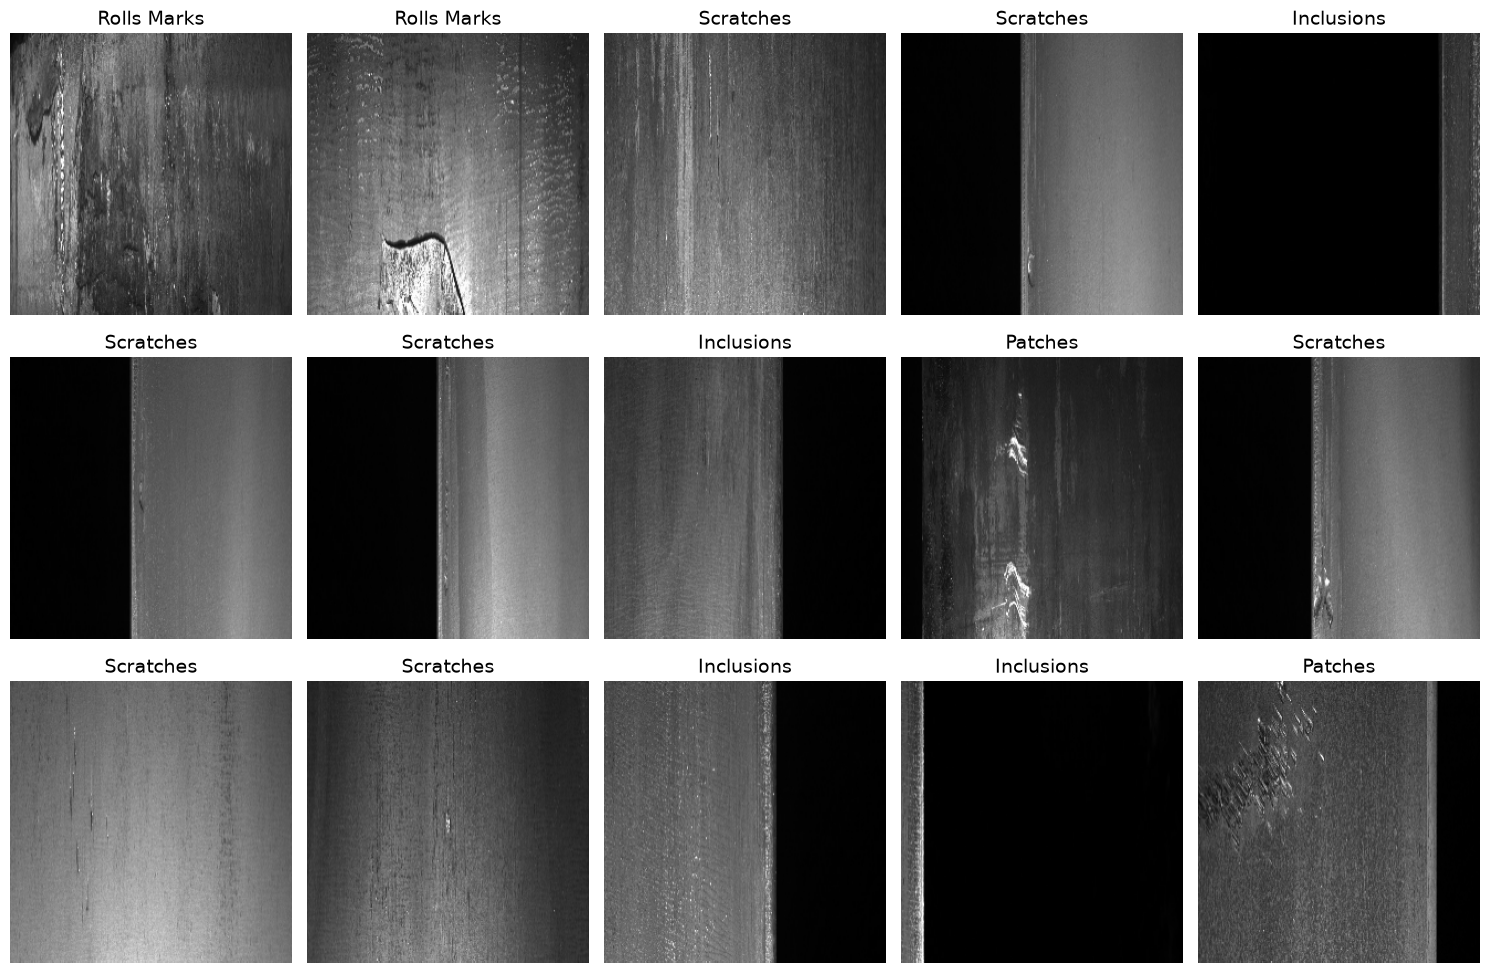

In [8]:
# Visualize sample images from training set
# (images are float [0,255]; just scale to [0,1] for display)
plt.figure(figsize=(15, 10))
images_batch, labels_batch = next(iter(train_ds))
images_batch = images_batch.numpy()
labels_batch = labels_batch.numpy()
for i in range(min(15, len(images_batch))):
    ax = plt.subplot(3, 5, i + 1)
    img = np.clip(images_batch[i] / 255.0, 0, 1)
    plt.imshow(img)
    plt.title(class_names[labels_batch[i]], fontsize=14)
    plt.axis('off')
plt.tight_layout()
plt.show()


## Data Augmentation

In [9]:
# ============================================================
# DATA AUGMENTATION (training split only)
# ============================================================
# Keras applies augmentation on-the-fly via preprocessing layers.
# These run only in training mode and only on the training dataset, so
# val/test evaluation stays clean.

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(30 / 360.0),                 # ~30 degrees
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomZoom(0.1),                            # ~scale 0.9-1.1
    layers.RandomBrightness(0.25, value_range=(0, 255)),
    layers.RandomContrast(0.25),
], name="data_augmentation")

# Apply augmentation to the training dataset (val/test unchanged).
# AUG_MULTIPLIER repeats the training set so each epoch sees several
# freshly-augmented passes, mirroring the original 4x augmentation.
AUG_MULTIPLIER = 4

AUTOTUNE = tf.data.AUTOTUNE
train_ds_aug = (
    make_ds(train_idx, shuffle=True)
    .repeat(AUG_MULTIPLIER)
    .map(lambda x, y: (data_augmentation(x, training=True), y),
         num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

# Steps per epoch since we use .repeat()
import math
STEPS_PER_EPOCH = math.ceil(n_train * AUG_MULTIPLIER / BATCH_SIZE)

# Reassign the training dataset used for fitting (val/test unchanged)
train_ds = train_ds_aug

print(f"Training samples: {n_train * AUG_MULTIPLIER} ({AUG_MULTIPLIER}x, on-the-fly augmentation)")
print(f"Validation samples: {n_val}")
print(f"Test samples:       {n_test}")


Training samples: 4744 (4x, on-the-fly augmentation)
Validation samples: 254
Test samples:       255


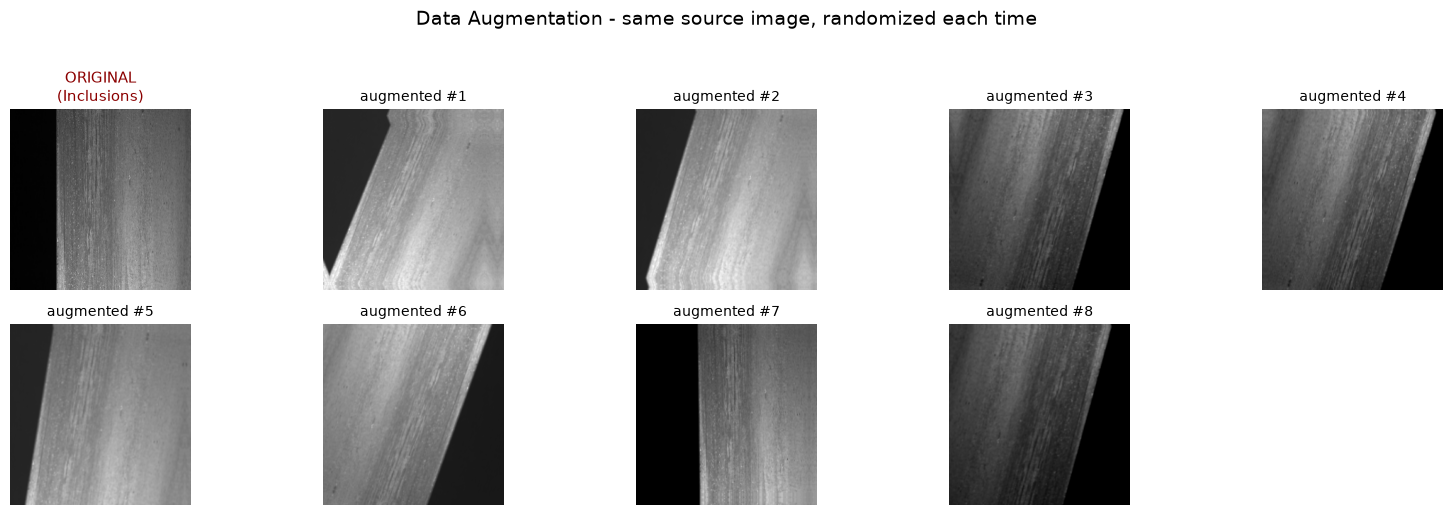

In [10]:
# --- Visualize the augmentations -----------------------------
import random

# Grab one RANDOM source image from the training split
sample_path = random.choice(all_paths[train_idx])
src_label = all_labels[train_idx][list(all_paths[train_idx]).index(sample_path)]

raw = tf.io.read_file(sample_path)
raw = tf.image.decode_image(raw, channels=3, expand_animations=False)
raw = tf.image.resize(raw, (IMAGE_SIZE, IMAGE_SIZE))
raw = tf.cast(raw, tf.float32)

n_show = 8
plt.figure(figsize=(16, 5))

ax = plt.subplot(2, (n_show // 2) + 1, 1)
plt.imshow(np.clip(raw.numpy() / 255.0, 0, 1))
plt.title(f"ORIGINAL\n({class_names[src_label]})", fontsize=11, color="darkred")
plt.axis("off")

for i in range(n_show):
    ax = plt.subplot(2, (n_show // 2) + 1, i + 2)
    aug = data_augmentation(tf.expand_dims(raw, 0), training=True)[0]
    img = np.clip(aug.numpy() / 255.0, 0, 1)
    plt.imshow(img)
    plt.title(f"augmented #{i+1}", fontsize=10)
    plt.axis("off")

plt.suptitle("Data Augmentation - same source image, randomized each time",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Transfer Learning with VGG16

In [11]:
## Transfer Learning with VGG16
def build_vgg16_model(num_classes):
    vgg16_backbone = VGG16(weights="imagenet", include_top=True)

    # Freeze all pretrained layers
    vgg16_backbone.trainable = False

    # Use VGG16 up to the second-to-last classifier layer ('fc2', 4096-d),
    # mirroring the PyTorch version that dropped the final 1000-way layer.
    feature_extractor = keras.Model(
        inputs=vgg16_backbone.input,
        outputs=vgg16_backbone.get_layer("fc2").output,
        name="vgg16_fc2"
    )
    feature_extractor.trainable = False

    inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    x = layers.Resizing(224, 224)(inputs)          # VGG16 expects 224x224
    x = layers.Lambda(vgg16_preprocess)(x)         # ImageNet preprocessing
    x = feature_extractor(x)                        # -> 4096-d features
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes)(x)          # logits (from_logits=True)

    model = keras.Model(inputs, outputs, name="vgg16_transfer")
    return model

# Build model
model_vgg16 = build_vgg16_model(num_classes=len(class_names))

# Model summary
total_params     = model_vgg16.count_params()
trainable_params = sum(int(tf.size(w)) for w in model_vgg16.trainable_weights)

print("VGG16 Transfer Learning Model")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 32s 0us/step

VGG16 Transfer Learning Model
Total parameters:     136,490,564
Trainable parameters: 2,230,020
Frozen parameters:    134,260,544


In [12]:
def train_model(model, train_ds, val_ds, optimizer, loss_fn, epochs,
                model_name="Model", steps_per_epoch=None):
    """Compile + fit a Keras model and return a history dict whose keys match
    the original notebook: 'loss', 'accuracy', 'val_loss', 'val_accuracy'."""
    model.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])

    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        verbose=1,
    )

    history = {
        "loss":         hist.history["loss"],
        "accuracy":     hist.history["accuracy"],
        "val_loss":     hist.history["val_loss"],
        "val_accuracy": hist.history["val_accuracy"],
    }
    print("\nTraining completed!")
    return history


In [13]:
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer_vgg16 = optimizers.Adam(learning_rate=0.001)
EPOCHS = 6

start = time.time()
print("Training VGG16 Transfer Learning Model...")
history_vgg16 = train_model(
    model_vgg16,
    train_ds,
    val_ds,
    optimizer_vgg16,
    loss_fn,
    EPOCHS,
    "VGG16",
    steps_per_epoch=STEPS_PER_EPOCH,
)
print("Time:", time.time() - start, "sec")
time_vgg16 = time.time() - start


Training VGG16 Transfer Learning Model...
Epoch 1/6


c:\Users\yuvarajendraan\.conda\envs\gpu\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


149/149 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - accuracy: 0.5378 - loss: 1.1557 - val_accuracy: 0.7047 - val_loss: 0.7947
Epoch 2/6
  3/149 ━━━━━━━━━━━━━━━━━━━━ 2:00 825ms/step - accuracy: 0.6212 - loss: 0.9489

c:\Users\yuvarajendraan\.conda\envs\gpu\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


149/149 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.6212 - loss: 0.9489 - val_accuracy: 0.6772 - val_loss: 0.7899
Epoch 3/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.6246 - loss: 0.8682 - val_accuracy: 0.6654 - val_loss: 0.7399
Epoch 4/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.6970 - loss: 0.8273 - val_accuracy: 0.6811 - val_loss: 0.7623
Epoch 5/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 0.6477 - loss: 0.8190 - val_accuracy: 0.6535 - val_loss: 0.7422
Epoch 6/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.6212 - loss: 0.8837 - val_accuracy: 0.6969 - val_loss: 0.6968

Training completed!
Time: 784.5131509304047 sec


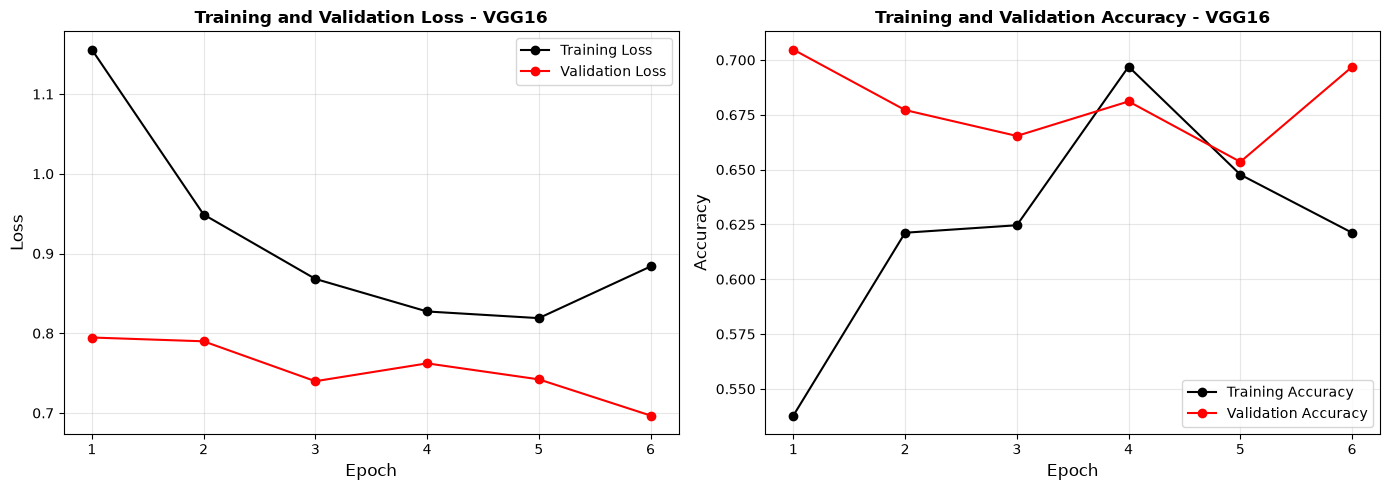

In [14]:
# Plot Training History for VGG16
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(np.arange(1, EPOCHS + 1), history_vgg16['loss'],
             color='black', label='Training Loss', marker='o')
axes[0].plot(np.arange(1, EPOCHS + 1), history_vgg16['val_loss'],
             color='red', label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss - VGG16', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.arange(1, EPOCHS + 1), history_vgg16['accuracy'],
             color='black', label='Training Accuracy', marker='o')
axes[1].plot(np.arange(1, EPOCHS + 1), history_vgg16['val_accuracy'],
             color='red', label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy - VGG16', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


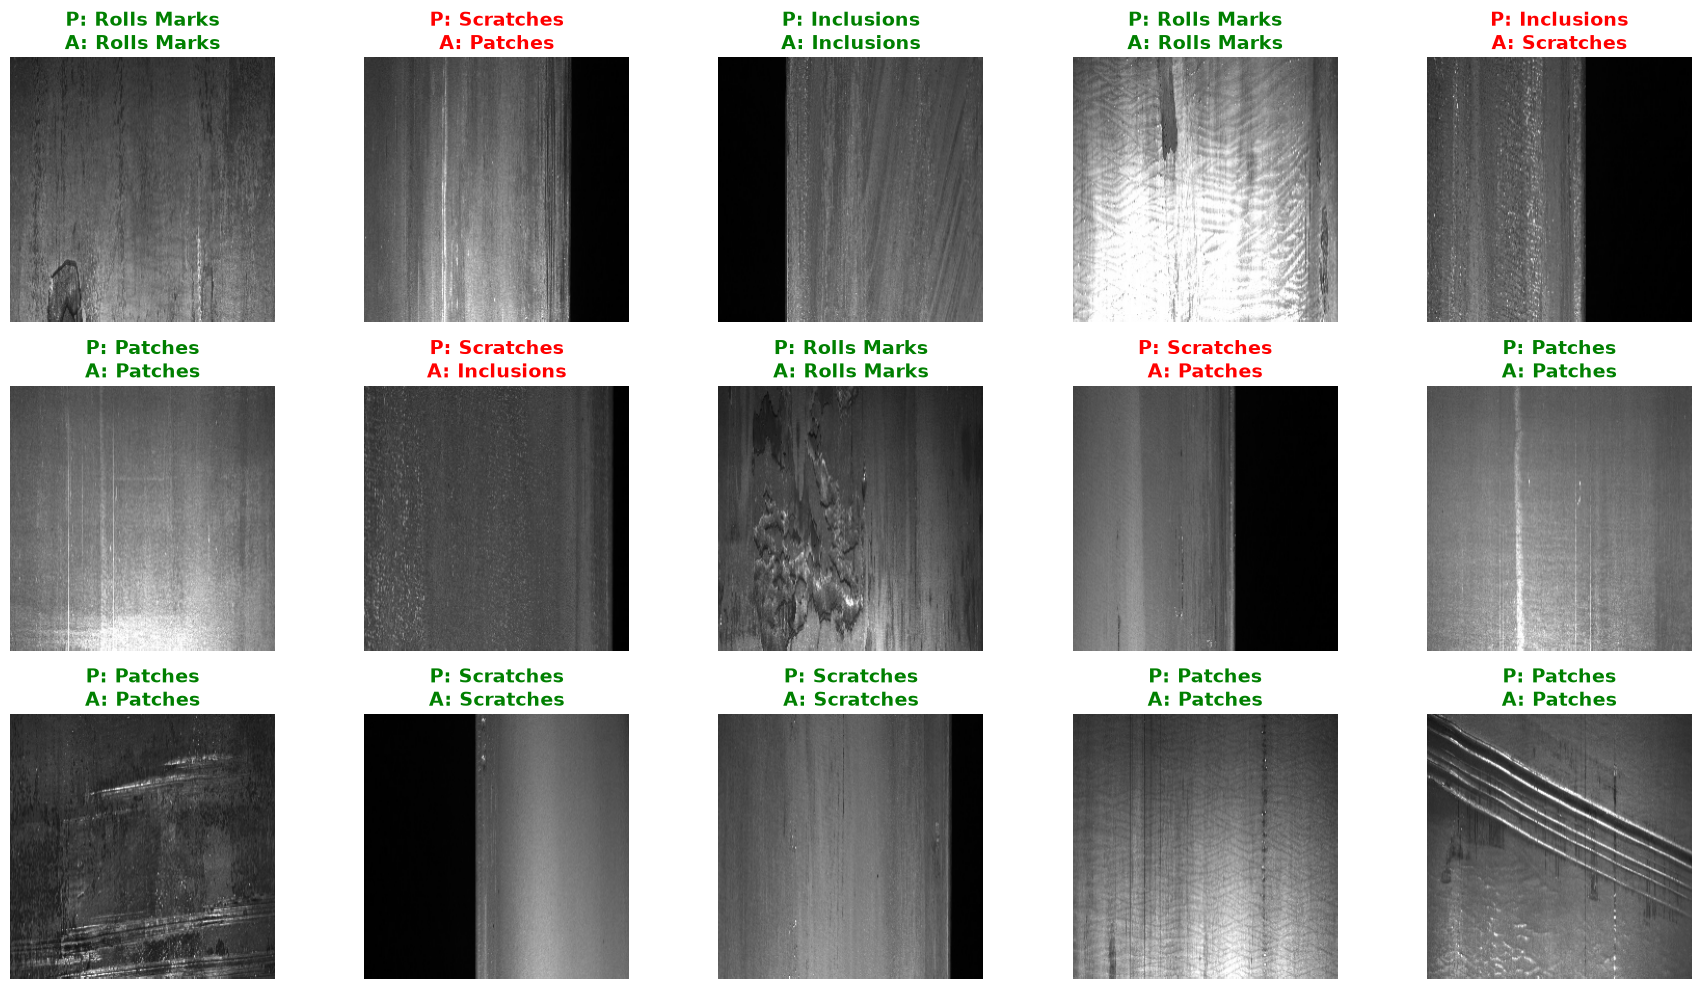

In [15]:
# Visualize Predictions on Test Set - VGG16
plt.figure(figsize=(18, 10))

images_batch, labels_batch = next(iter(test_ds))
images_batch = images_batch.numpy()
labels_batch = labels_batch.numpy()

logits = model_vgg16.predict(images_batch, verbose=0)
predicted_classes = np.argmax(logits, axis=1)

for i in range(min(15, len(images_batch))):
    ax = plt.subplot(3, 5, i + 1)
    img = np.clip(images_batch[i] / 255.0, 0, 1)
    plt.imshow(img)

    actual_class_idx = int(labels_batch[i])
    actual_class     = class_names[actual_class_idx]
    predicted_class  = class_names[int(predicted_classes[i])]

    color = 'green' if actual_class_idx == int(predicted_classes[i]) else 'red'
    plt.title(f"P: {predicted_class}\nA: {actual_class}",
              color=color, fontweight='bold', fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()


Computing predictions on test set...
Test Accuracy: 0.6784 (67.84%)


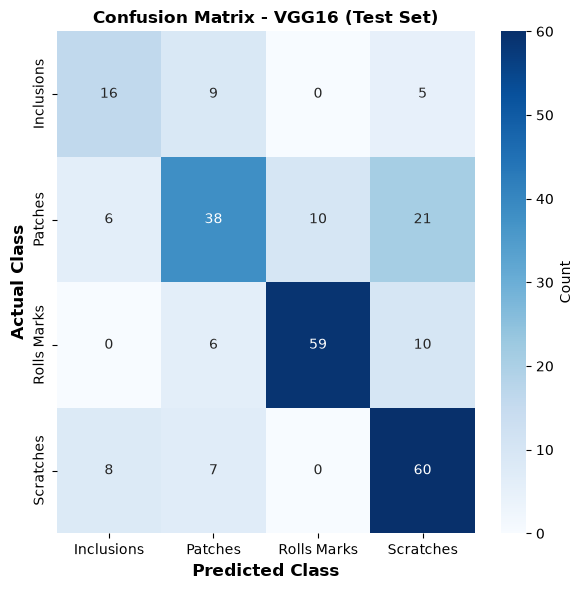


CLASSIFICATION REPORT - VGG16 (Test Set)
              precision    recall  f1-score   support

  Inclusions     0.5333    0.5333    0.5333        30
     Patches     0.6333    0.5067    0.5630        75
 Rolls Marks     0.8551    0.7867    0.8194        75
   Scratches     0.6250    0.8000    0.7018        75

    accuracy                         0.6784       255
   macro avg     0.6617    0.6567    0.6544       255
weighted avg     0.6843    0.6784    0.6757       255



In [16]:
# Confusion Matrix and Classification Report - VGG16 (Test)
print("Computing predictions on test set...")
ypred_test, ylabel_test = [], []

for images, labels in test_ds:
    logits = model_vgg16.predict(images, verbose=0)
    predicted = np.argmax(logits, axis=1)
    ypred_test.extend(predicted)
    ylabel_test.extend(labels.numpy())

cm_test = confusion_matrix(ylabel_test, ypred_test)
test_accuracy = np.sum(np.array(ypred_test) == np.array(ylabel_test)) / len(ylabel_test)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*60)

plt.figure(figsize=(6, 6))
sns.heatmap(cm_test, annot=True, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            fmt='d', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('Actual Class', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - VGG16 (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CLASSIFICATION REPORT - VGG16 (Test Set)")
print("="*60)
print(classification_report(ylabel_test, ypred_test,
                             labels=list(range(len(class_names))),
                             target_names=class_names, digits=4))
print("="*60)


In [17]:
# Save VGG16 Model
model_vgg16.save('model_vgg16_model.keras')
print("VGG16 model saved as 'model_vgg16_model.keras'")


VGG16 model saved as 'model_vgg16_model.keras'


## Fine-tuning VGG16 - Unfreezing the last Conv block (block5) 

## Fine-Tuning: Unfreezing the Last Conv Block

So far the entire VGG16 backbone was frozen and only the new classifier head was trained (~2.23M parameters). We now **unfreeze the last convolutional block (block5)** so its filters can adapt from generic ImageNet features to the specific textures and patterns of steel-surface defects.

This raises the trainable parameter count to roughly **9.3M**, since block5's three convolutional layers add about 7M trainable weights on top of the head.

**Why this can affect results:**
- **Upside** — the deepest conv features become specialized to our defect classes, which can improve accuracy when the target domain differs from ImageNet.
- **Risk** — more trainable parameters on a small dataset (~1,186 unique images) increases the chance of **overfitting**. To mitigate this, we keep the early blocks frozen (their edge/texture features generalize well) and fine-tune the backbone with a **much lower learning rate** than the head, so the pretrained weights are nudged rather than overwritten.

In [18]:
## Transfer Learning with VGG16 - last conv block (block5) unfrozen for fine-tuning
def build_vgg16_model_ft(num_classes):
    vgg16_backbone_ft = VGG16(weights="imagenet", include_top=True)
    vgg16_backbone_ft.trainable = False

    feature_extractor = keras.Model(
        inputs=vgg16_backbone_ft.input,
        outputs=vgg16_backbone_ft.get_layer("fc2").output,
        name="vgg16_fc2_ft"
    )

    inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    x = layers.Resizing(224, 224)(inputs)
    x = layers.Lambda(vgg16_preprocess)(x)
    x = feature_extractor(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes)(x)

    model = keras.Model(inputs, outputs, name="vgg16_transfer_ft")
    # keep a handle to the backbone for selective unfreezing
    model.feature_extractor = feature_extractor
    return model


def unfreeze_vgg16_block5(model):
    """Unfreeze VGG16's last conv block (block5) for fine-tuning.

    In Keras' VGG16 the block5 conv layers are named 'block5_conv1/2/3'.
    Everything before stays frozen so generic early features are preserved.
    """
    fe = model.feature_extractor
    fe.trainable = True
    for layer in fe.layers:
        layer.trainable = layer.name.startswith("block5_conv")
    return model


# Build model
model_vgg16_ft = build_vgg16_model_ft(num_classes=len(class_names))

# Unfreeze the last conv block for fine-tuning
model_vgg16_ft = unfreeze_vgg16_block5(model_vgg16_ft)

# Model summary
total_params     = model_vgg16_ft.count_params()
trainable_params = sum(int(tf.size(w)) for w in model_vgg16_ft.trainable_weights)

print("VGG16 Fine-Tuning Model (block5 unfrozen)")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")


VGG16 Fine-Tuning Model (block5 unfrozen)
Total parameters:     136,490,564
Trainable parameters: 9,309,444
Frozen parameters:    127,181,120


In [19]:
# Training the fine-tuned VGG16 model - last conv block (block5) unfrozen for fine-tuning
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer_vgg16_ft = optimizers.Adam(learning_rate=0.001)
EPOCHS = 6

start = time.time()
print("Training VGG16 Transfer Learning Model...")
history_vgg16_ft = train_model(
    model_vgg16_ft,
    train_ds,
    val_ds,
    optimizer_vgg16_ft,
    loss_fn,
    EPOCHS,
    "VGG16",
    steps_per_epoch=STEPS_PER_EPOCH,
)
print("Time:", time.time() - start, "sec")
time_vgg16_ft = time.time() - start


Training VGG16 Transfer Learning Model...
Epoch 1/6


c:\Users\yuvarajendraan\.conda\envs\gpu\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


149/149 ━━━━━━━━━━━━━━━━━━━━ 291s 2s/step - accuracy: 0.3833 - loss: 1.4103 - val_accuracy: 0.5669 - val_loss: 0.9473
Epoch 2/6
  3/149 ━━━━━━━━━━━━━━━━━━━━ 3:55 2s/step - accuracy: 0.3939 - loss: 1.1961

c:\Users\yuvarajendraan\.conda\envs\gpu\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


149/149 ━━━━━━━━━━━━━━━━━━━━ 25s 148ms/step - accuracy: 0.3939 - loss: 1.1961 - val_accuracy: 0.5866 - val_loss: 0.9685
Epoch 3/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 422s 3s/step - accuracy: 0.5601 - loss: 0.9570 - val_accuracy: 0.6142 - val_loss: 0.8109
Epoch 4/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 23s 145ms/step - accuracy: 0.5909 - loss: 0.8774 - val_accuracy: 0.6654 - val_loss: 0.7581
Epoch 5/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 423s 3s/step - accuracy: 0.6691 - loss: 0.7720 - val_accuracy: 0.6535 - val_loss: 0.6809
Epoch 6/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 24s 143ms/step - accuracy: 0.7273 - loss: 0.6327 - val_accuracy: 0.6457 - val_loss: 0.6985

Training completed!
Time: 1207.8839099407196 sec


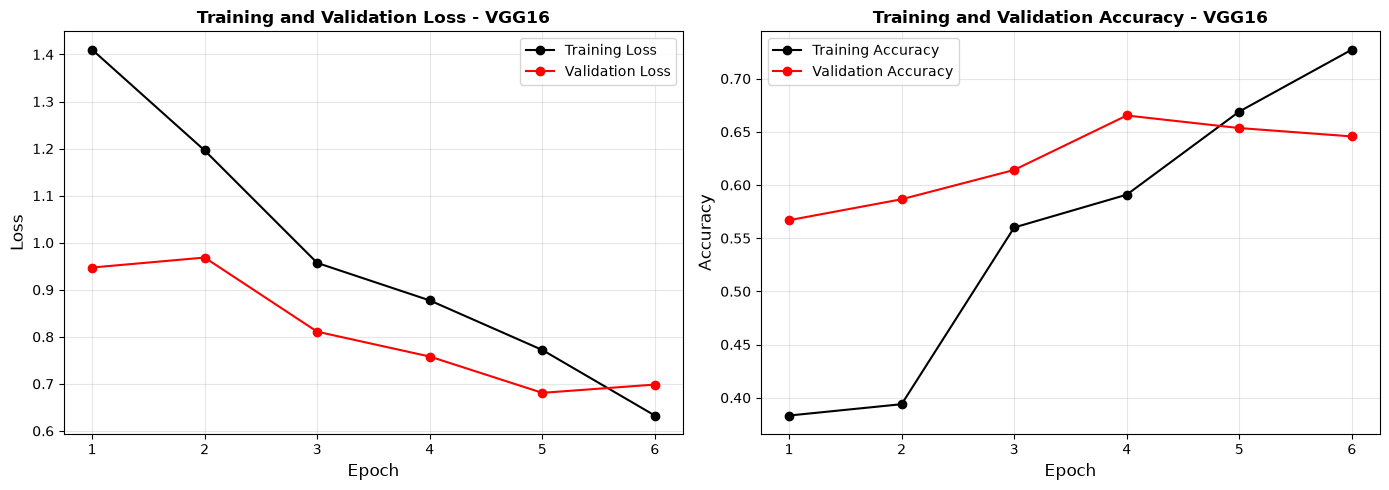

In [20]:
# Plot Training History for VGG16 - last conv block (block5) unfrozen for fine-tuning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(np.arange(1, EPOCHS + 1), history_vgg16_ft['loss'],
             color='black', label='Training Loss', marker='o')
axes[0].plot(np.arange(1, EPOCHS + 1), history_vgg16_ft['val_loss'],
             color='red', label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss - VGG16', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.arange(1, EPOCHS + 1), history_vgg16_ft['accuracy'],
             color='black', label='Training Accuracy', marker='o')
axes[1].plot(np.arange(1, EPOCHS + 1), history_vgg16_ft['val_accuracy'],
             color='red', label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy - VGG16', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


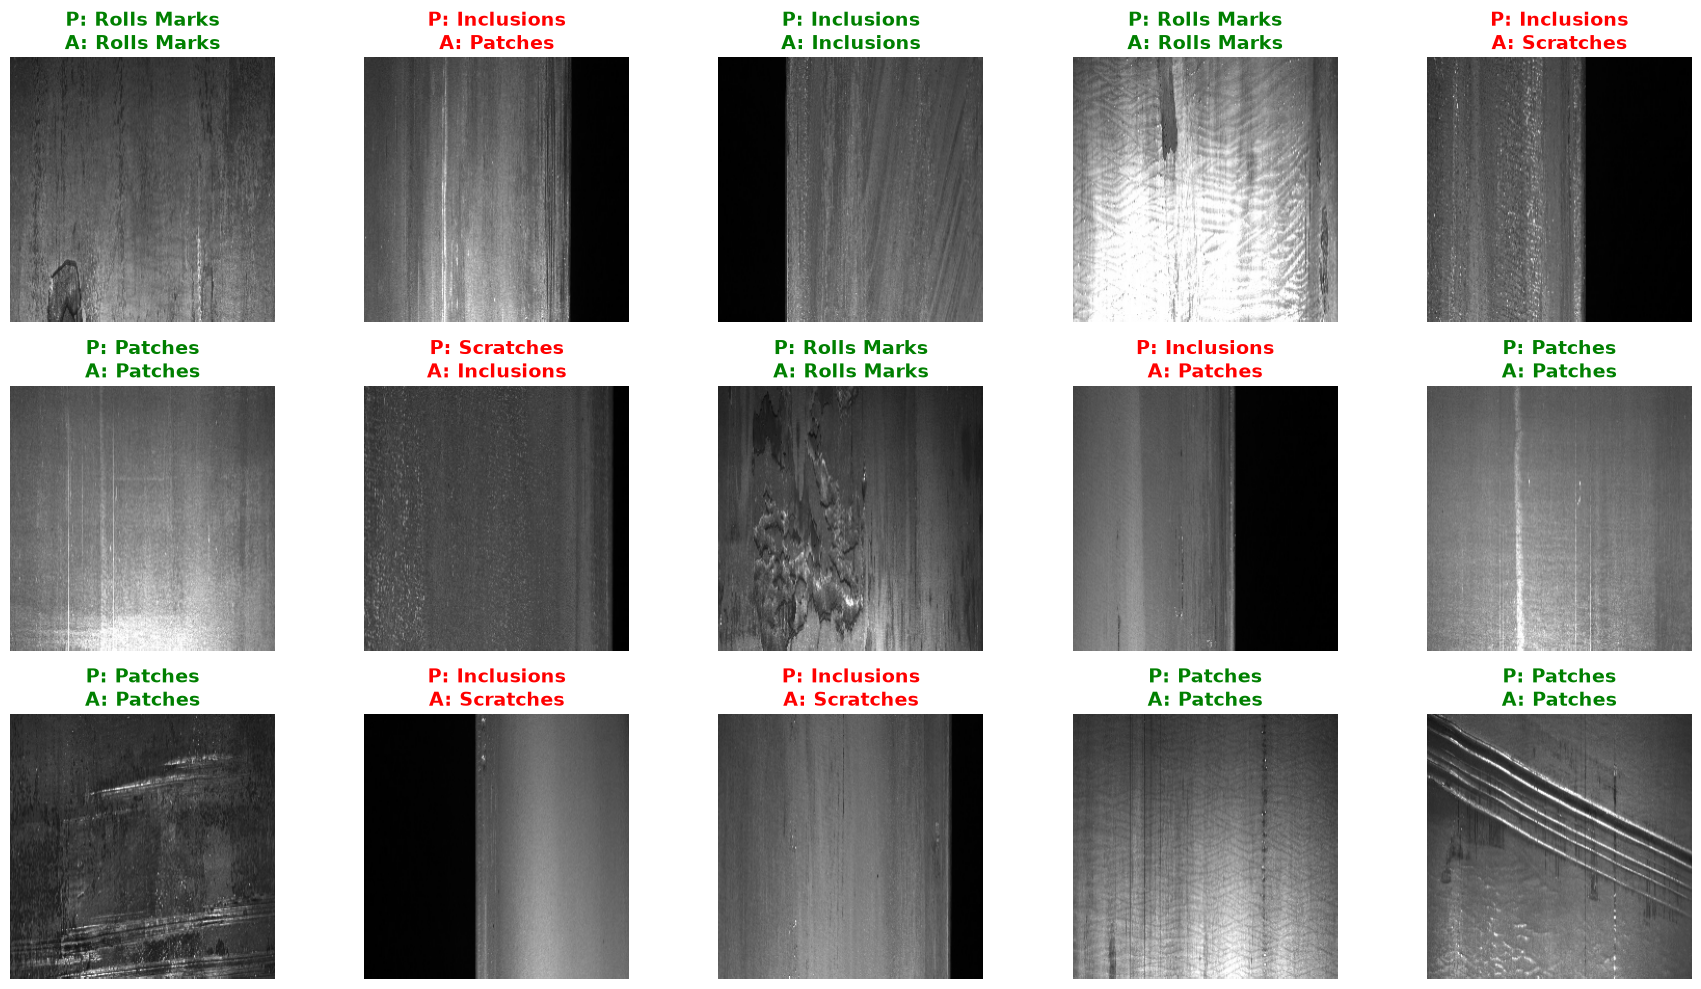

In [21]:
# Visualize Predictions on Test Set - VGG16 fine-tuned (block5 unfrozen)
plt.figure(figsize=(18, 10))

images_batch, labels_batch = next(iter(test_ds))
images_batch = images_batch.numpy()
labels_batch = labels_batch.numpy()

logits = model_vgg16_ft.predict(images_batch, verbose=0)
predicted_classes = np.argmax(logits, axis=1)

for i in range(min(15, len(images_batch))):
    ax = plt.subplot(3, 5, i + 1)
    img = np.clip(images_batch[i] / 255.0, 0, 1)
    plt.imshow(img)

    actual_class_idx = int(labels_batch[i])
    actual_class     = class_names[actual_class_idx]
    predicted_class  = class_names[int(predicted_classes[i])]

    color = 'green' if actual_class_idx == int(predicted_classes[i]) else 'red'
    plt.title(f"P: {predicted_class}\nA: {actual_class}",
              color=color, fontweight='bold', fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()


Computing predictions on test set...
Test Accuracy: 0.6078 (60.78%)


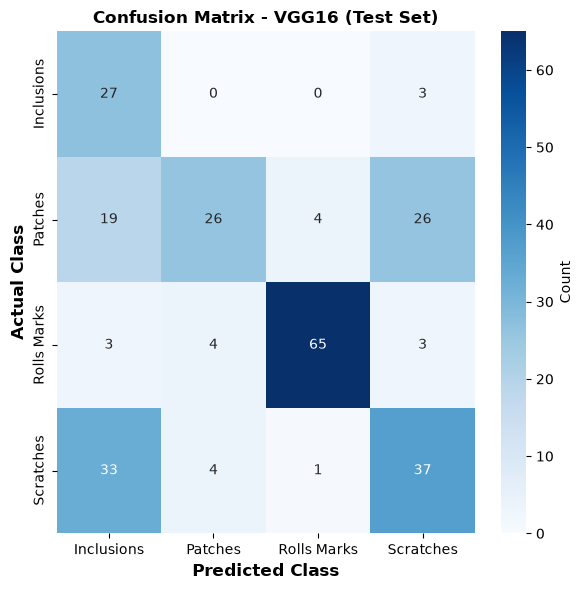


CLASSIFICATION REPORT - VGG16 (Test Set)
              precision    recall  f1-score   support

  Inclusions     0.3293    0.9000    0.4821        30
     Patches     0.7647    0.3467    0.4771        75
 Rolls Marks     0.9286    0.8667    0.8966        75
   Scratches     0.5362    0.4933    0.5139        75

    accuracy                         0.6078       255
   macro avg     0.6397    0.6517    0.5924       255
weighted avg     0.6945    0.6078    0.6119       255



In [22]:
# Confusion Matrix and Classification Report - VGG16 (Test)
print("Computing predictions on test set...")
ypred_test, ylabel_test = [], []

for images, labels in test_ds:
    logits = model_vgg16_ft.predict(images, verbose=0)
    predicted = np.argmax(logits, axis=1)
    ypred_test.extend(predicted)
    ylabel_test.extend(labels.numpy())

cm_test = confusion_matrix(ylabel_test, ypred_test)
test_accuracy = np.sum(np.array(ypred_test) == np.array(ylabel_test)) / len(ylabel_test)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*60)

plt.figure(figsize=(6, 6))
sns.heatmap(cm_test, annot=True, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            fmt='d', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('Actual Class', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - VGG16 (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CLASSIFICATION REPORT - VGG16 (Test Set)")
print("="*60)
print(classification_report(ylabel_test, ypred_test,
                             labels=list(range(len(class_names))),
                             target_names=class_names, digits=4))
print("="*60)


## Assignment: Transfer Learning with MobileNetV2

MobileNetV2 (Google, 2018) is a lightweight CNN designed for speed and efficiency on mobile and edge devices. Its key trick is the **depthwise separable convolution** — splitting a normal convolution into a cheap per-channel spatial filter followed by a 1×1 channel-mixing step — combined with **inverted residual blocks** that expand, filter, then compress the channels, with skip connections between the narrow ends.

The result is a model with only **~3.4M parameters** (vs. VGG16's ~138M) that still reaches solid ImageNet accuracy. This efficiency makes it a strong transfer-learning choice for our small dataset: fewer parameters mean faster training and less risk of overfitting.
Apply transfer learning using MobileNetV2 to build an image classification model for Steel Defect Detection dataset.
You are required to:
Load a pretrained MobileNetV2 model from torchvision. Inspect the model architecture and explore its parameters and layers.
Freeze the pretrained feature extractor layers.
Replace the classifier with a custom neural network head.
Train the model on your dataset.
Evaluate performance on validation data.
Compare results with previous VGG16 model.

## Solution

In [23]:
# Load pre-trained MobileNetV2 base model
base_model_mbv2 = MobileNetV2(weights="imagenet", include_top=False,
                              input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

# Freeze base model weights
base_model_mbv2.trainable = False

total_params = base_model_mbv2.count_params()
trainable = sum(int(tf.size(w)) for w in base_model_mbv2.trainable_weights)
print(f"Base model loaded with {total_params:,} parameters")
print(f"Trainable params (frozen): {trainable:,}")


C:\Users\yuvarajendraan\AppData\Local\Temp\ipykernel_2180\2002338867.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_mbv2 = MobileNetV2(weights="imagenet", include_top=False,


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Base model loaded with 2,257,984 parameters
Trainable params (frozen): 0


In [24]:
# Build Transfer Learning Model with MobileNetV2
def build_mobilenetv2_model():
    base = MobileNetV2(weights="imagenet", include_top=False,
                       input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    base.trainable = False  # Freeze all base layers

    inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    x = layers.Lambda(mbv2_preprocess)(inputs)     # MobileNetV2 preprocessing
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)         # equivalent to torchvision pooling
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(len(class_names))(x)

    return keras.Model(inputs, outputs, name="mobilenetv2_transfer")

model_mbv2 = build_mobilenetv2_model()

trainable = sum(int(tf.size(w)) for w in model_mbv2.trainable_weights)
total     = model_mbv2.count_params()
print(f"\nMobileNetV2 Transfer Learning Model")
print(f"Total parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}")


C:\Users\yuvarajendraan\AppData\Local\Temp\ipykernel_2180\1285367598.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(weights="imagenet", include_top=False,



MobileNetV2 Transfer Learning Model
Total parameters:     2,586,948
Trainable parameters: 328,964


In [25]:
# Train MobileNetV2 Model
EPOCHS = 6
start = time.time()
optimizer_mbv2 = optimizers.Adam(learning_rate=0.001)
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
print("Training MobileNetV2 Transfer Learning Model...")
history_mbv2 = train_model(model_mbv2, train_ds, val_ds,
                           optimizer_mbv2, loss_fn, EPOCHS, "MobileNetV2",
                           steps_per_epoch=STEPS_PER_EPOCH)
print("Time:", time.time() - start, "sec")
time_mbv2 = time.time() - start


Training MobileNetV2 Transfer Learning Model...
Epoch 1/6


c:\Users\yuvarajendraan\.conda\envs\gpu\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


149/149 ━━━━━━━━━━━━━━━━━━━━ 50s 285ms/step - accuracy: 0.6494 - loss: 0.8426 - val_accuracy: 0.6299 - val_loss: 0.7574
Epoch 2/6
  3/149 ━━━━━━━━━━━━━━━━━━━━ 21s 148ms/step - accuracy: 0.7424 - loss: 0.6652

c:\Users\yuvarajendraan\.conda\envs\gpu\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7424 - loss: 0.6652 - val_accuracy: 0.5906 - val_loss: 0.8300
Epoch 3/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 42s 273ms/step - accuracy: 0.7413 - loss: 0.6298 - val_accuracy: 0.7087 - val_loss: 0.7048
Epoch 4/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7727 - loss: 0.5141 - val_accuracy: 0.7087 - val_loss: 0.7011
Epoch 5/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 42s 275ms/step - accuracy: 0.7580 - loss: 0.5942 - val_accuracy: 0.6614 - val_loss: 0.7470
Epoch 6/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7879 - loss: 0.7073 - val_accuracy: 0.7402 - val_loss: 0.6420

Training completed!
Time: 142.40450954437256 sec


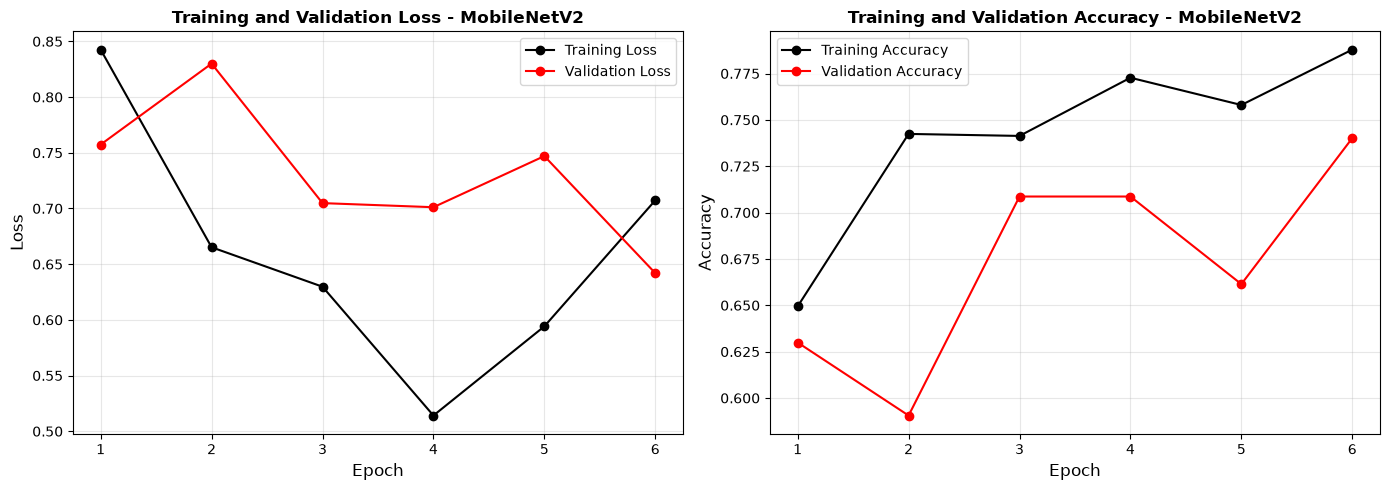

In [26]:
# Plot Training History for MobileNetV2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(np.arange(1, EPOCHS + 1), history_mbv2['loss'],
             color='black', label='Training Loss', marker='o')
axes[0].plot(np.arange(1, EPOCHS + 1), history_mbv2['val_loss'],
             color='red', label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss - MobileNetV2', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.arange(1, EPOCHS + 1), history_mbv2['accuracy'],
             color='black', label='Training Accuracy', marker='o')
axes[1].plot(np.arange(1, EPOCHS + 1), history_mbv2['val_accuracy'],
             color='red', label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy - MobileNetV2', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


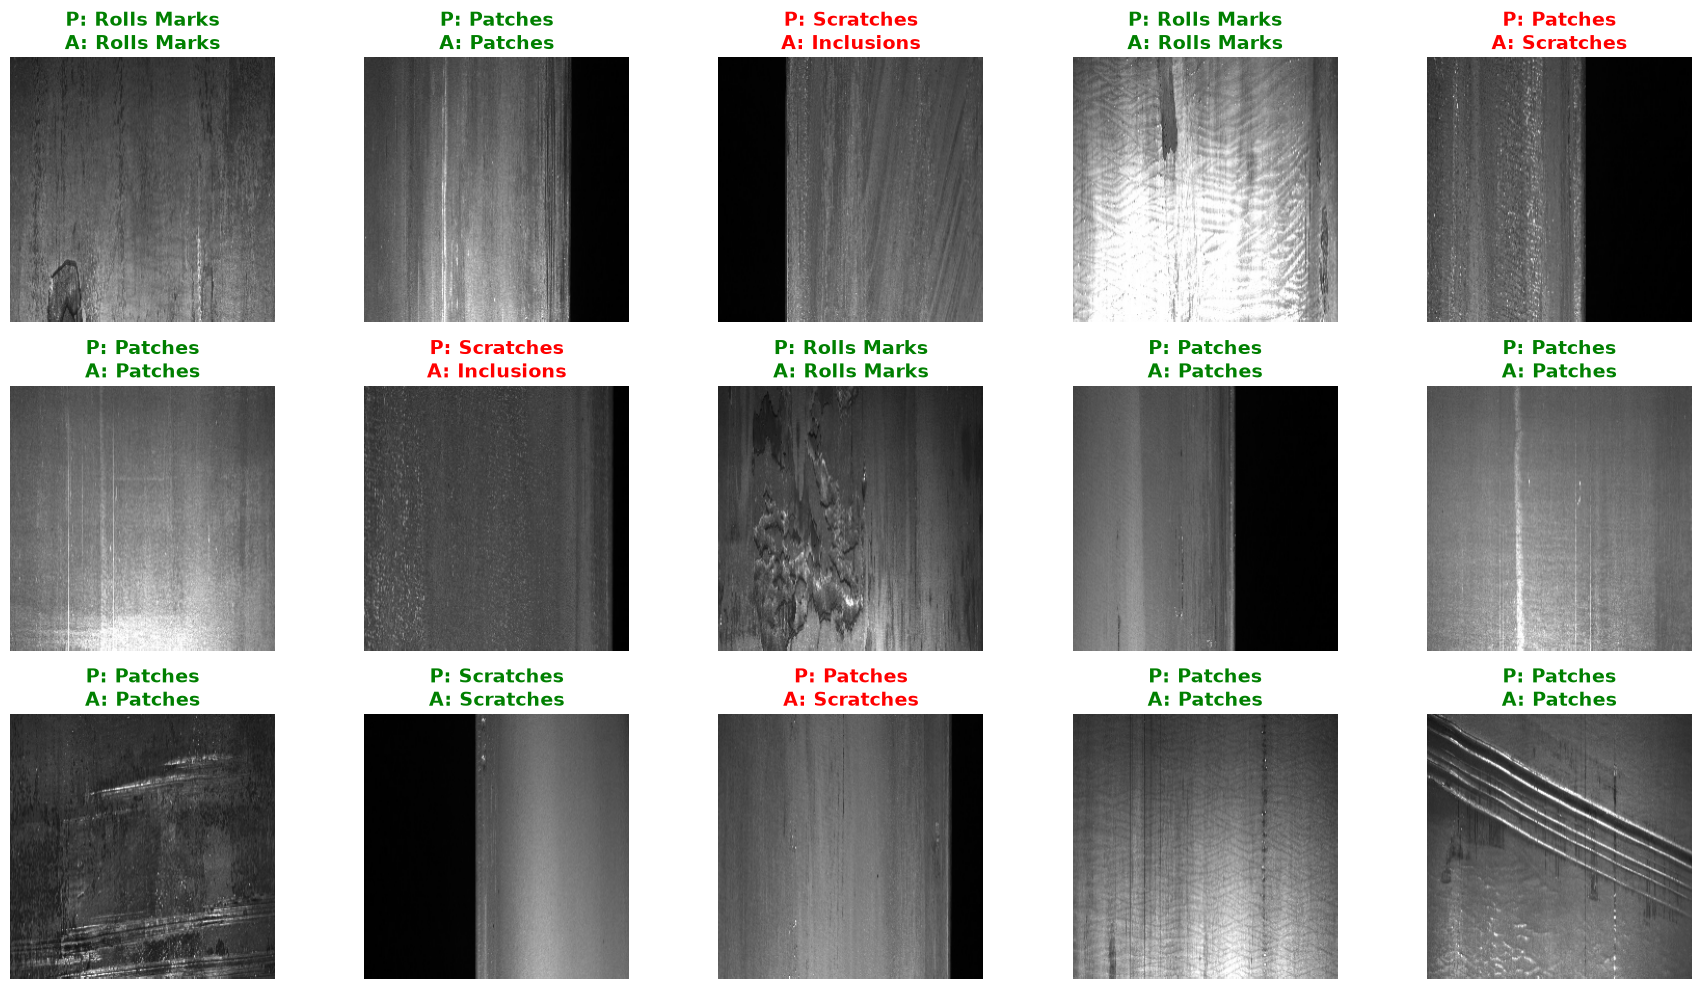

In [27]:
# Visualize Predictions on Test Set - MobileNetV2
plt.figure(figsize=(18, 10))

images_batch, labels_batch = next(iter(test_ds))
images_batch = images_batch.numpy()
labels_batch = labels_batch.numpy()

logits = model_mbv2.predict(images_batch, verbose=0)
predicted_classes = np.argmax(logits, axis=1)

for i in range(min(15, len(images_batch))):
    ax = plt.subplot(3, 5, i + 1)
    img = np.clip(images_batch[i] / 255.0, 0, 1)
    plt.imshow(img)

    actual_class_idx = int(labels_batch[i])
    actual_class     = class_names[actual_class_idx]
    predicted_class  = class_names[int(predicted_classes[i])]

    color = 'green' if actual_class_idx == int(predicted_classes[i]) else 'red'
    plt.title(f"P: {predicted_class}\nA: {actual_class}",
              color=color, fontweight='bold', fontsize=14)
    plt.axis('off')

plt.tight_layout()
plt.show()


Computing predictions on test set...
Test Accuracy: 0.7255 (72.55%)


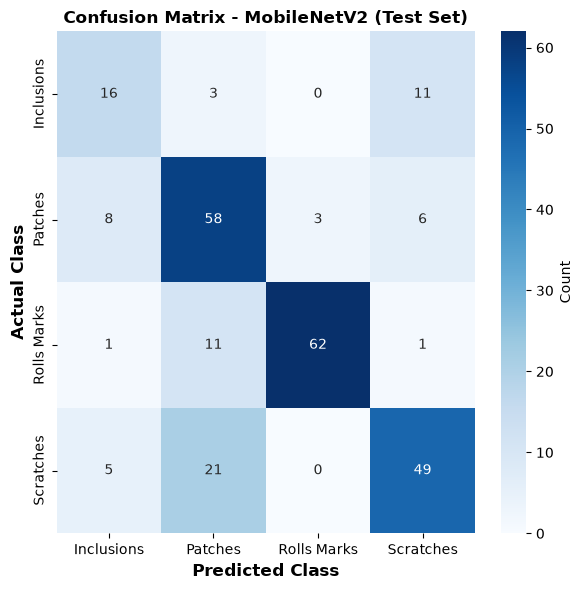


CLASSIFICATION REPORT - MobileNetV2 (Test Set)
              precision    recall  f1-score   support

  Inclusions     0.5333    0.5333    0.5333        30
     Patches     0.6237    0.7733    0.6905        75
 Rolls Marks     0.9538    0.8267    0.8857        75
   Scratches     0.7313    0.6533    0.6901        75

    accuracy                         0.7255       255
   macro avg     0.7105    0.6967    0.6999       255
weighted avg     0.7418    0.7255    0.7293       255



In [28]:
# Confusion Matrix and Classification Report - MobileNetV2 (Test)
print("Computing predictions on test set...")
ypred_test, ylabel_test = [], []

for images, labels in test_ds:
    logits = model_mbv2.predict(images, verbose=0)
    predicted = np.argmax(logits, axis=1)
    ypred_test.extend(predicted)
    ylabel_test.extend(labels.numpy())

cm_test = confusion_matrix(ylabel_test, ypred_test)
test_accuracy = np.sum(np.array(ypred_test) == np.array(ylabel_test)) / len(ylabel_test)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*60)

plt.figure(figsize=(6, 6))
sns.heatmap(cm_test, annot=True, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            fmt='d', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('Actual Class', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - MobileNetV2 (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CLASSIFICATION REPORT - MobileNetV2 (Test Set)")
print("="*60)
print(classification_report(ylabel_test, ypred_test,
                             labels=list(range(len(class_names))),
                             target_names=class_names, digits=4))
print("="*60)


In [29]:
# Save MobileNetV2 Model
model_mbv2.save('mobilenetv2_model.keras')
print("MobileNetV2 model saved as 'mobilenetv2_model.keras'")


MobileNetV2 model saved as 'mobilenetv2_model.keras'


## Transfer Learning with ResNet50

In [30]:
# Load pre-trained ResNet50 base model with ImageNet weights
base_model_resnet = ResNet50(weights="imagenet", include_top=False,
                             input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
base_model_resnet.trainable = False

total_params = base_model_resnet.count_params()
print(f"ResNet50 loaded with {total_params:,} parameters")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
ResNet50 loaded with 23,587,712 parameters


In [31]:
# Build ResNet50 Transfer Learning Model
def build_resnet50_model():
    base = ResNet50(weights="imagenet", include_top=False,
                    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    base.trainable = False  # Freeze all base layers

    inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    x = layers.Lambda(resnet_preprocess)(inputs)   # ResNet preprocessing
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)         # replaces avgpool before fc
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(len(class_names))(x)

    model = keras.Model(inputs, outputs, name="resnet50_transfer")
    model.head_layers = model.layers[-5:]  # handle to the new head (for optimizer note)
    return model

model_resnet = build_resnet50_model()

trainable = sum(int(tf.size(w)) for w in model_resnet.trainable_weights)
total     = model_resnet.count_params()
print(f"\nResNet50 Transfer Learning Model")
print(f"Total parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}")



ResNet50 Transfer Learning Model
Total parameters:     24,113,284
Trainable parameters: 525,572


In [32]:
# Train ResNet50 Model
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer_resnet = optimizers.Adam(learning_rate=0.001)
EPOCHS = 6

start = time.time()

print("Training ResNet50 Transfer Learning Model...")
history_resnet = train_model(model_resnet, train_ds, val_ds,
                             optimizer_resnet, loss_fn, EPOCHS, "ResNet50",
                             steps_per_epoch=STEPS_PER_EPOCH)
print("Time:", time.time() - start, "sec")
time_resnet = time.time() - start


Training ResNet50 Transfer Learning Model...
Epoch 1/6


c:\Users\yuvarajendraan\.conda\envs\gpu\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


149/149 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.6708 - loss: 0.7780 - val_accuracy: 0.7992 - val_loss: 0.5323
Epoch 2/6
  3/149 ━━━━━━━━━━━━━━━━━━━━ 1:33 639ms/step - accuracy: 0.7273 - loss: 0.7547

c:\Users\yuvarajendraan\.conda\envs\gpu\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


149/149 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.7273 - loss: 0.7547 - val_accuracy: 0.7441 - val_loss: 0.5971
Epoch 3/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.7572 - loss: 0.5954 - val_accuracy: 0.7362 - val_loss: 0.6057
Epoch 4/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.7879 - loss: 0.6266 - val_accuracy: 0.7795 - val_loss: 0.5335
Epoch 5/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 273s 2s/step - accuracy: 0.7929 - loss: 0.5137 - val_accuracy: 0.8189 - val_loss: 0.4973
Epoch 6/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 19s 117ms/step - accuracy: 0.7879 - loss: 0.6504 - val_accuracy: 0.8150 - val_loss: 0.5012

Training completed!
Time: 693.1109845638275 sec


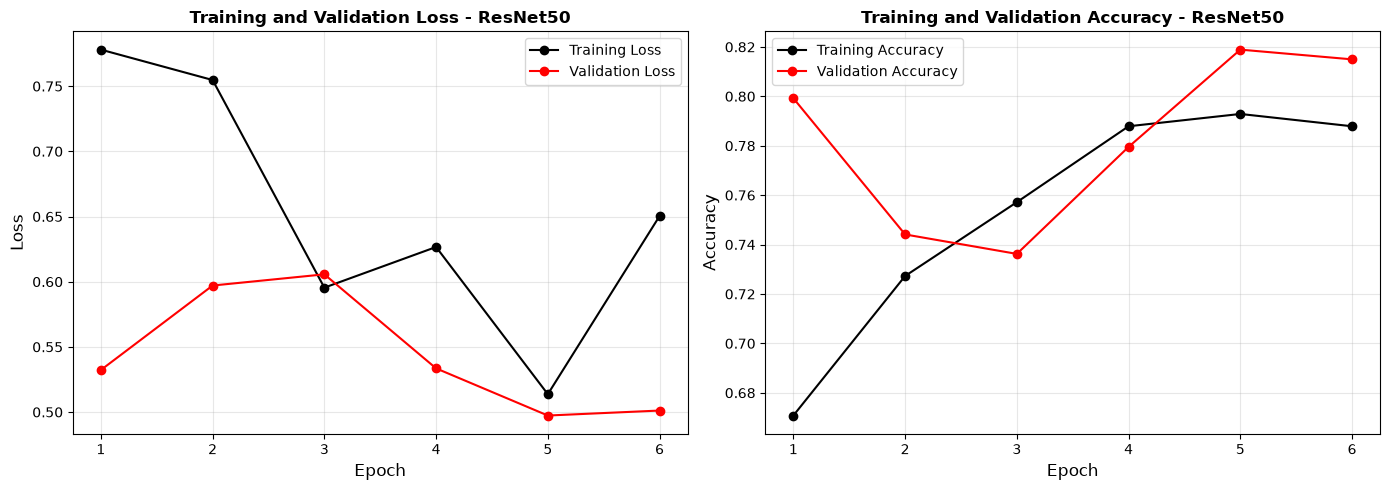

In [33]:
# Plot Training History for ResNet50
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(np.arange(1, EPOCHS + 1), history_resnet['loss'],
             color='black', label='Training Loss', marker='o')
axes[0].plot(np.arange(1, EPOCHS + 1), history_resnet['val_loss'],
             color='red', label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss - ResNet50', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.arange(1, EPOCHS + 1), history_resnet['accuracy'],
             color='black', label='Training Accuracy', marker='o')
axes[1].plot(np.arange(1, EPOCHS + 1), history_resnet['val_accuracy'],
             color='red', label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy - ResNet50', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Computing predictions on test set...
Test Accuracy: 0.7647 (76.47%)


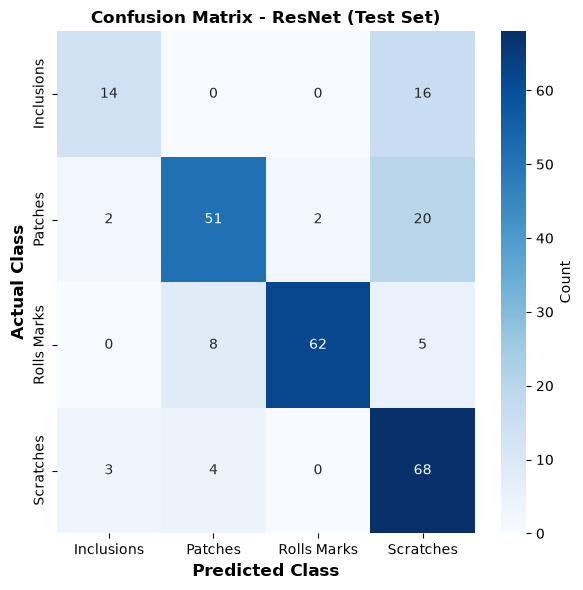


CLASSIFICATION REPORT - ResNet (Test Set)
              precision    recall  f1-score   support

  Inclusions     0.7368    0.4667    0.5714        30
     Patches     0.8095    0.6800    0.7391        75
 Rolls Marks     0.9688    0.8267    0.8921        75
   Scratches     0.6239    0.9067    0.7391        75

    accuracy                         0.7647       255
   macro avg     0.7847    0.7200    0.7354       255
weighted avg     0.7932    0.7647    0.7644       255



In [34]:
# Confusion Matrix and Classification Report - ResNet (Test)
print("Computing predictions on test set...")
ypred_test, ylabel_test = [], []

for images, labels in test_ds:
    logits = model_resnet.predict(images, verbose=0)
    predicted = np.argmax(logits, axis=1)
    ypred_test.extend(predicted)
    ylabel_test.extend(labels.numpy())

cm_test = confusion_matrix(ylabel_test, ypred_test)
test_accuracy = np.sum(np.array(ypred_test) == np.array(ylabel_test)) / len(ylabel_test)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*60)

plt.figure(figsize=(6, 6))
sns.heatmap(cm_test, annot=True, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            fmt='d', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('Actual Class', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - ResNet (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CLASSIFICATION REPORT - ResNet (Test Set)")
print("="*60)
print(classification_report(ylabel_test, ypred_test,
                             labels=list(range(len(class_names))),
                             target_names=class_names, digits=4))
print("="*60)


In [35]:
# Save ResNet50 Model
model_resnet.save('resnet50_model.keras')
print("ResNet50 model saved as 'resnet50_model.keras'")


ResNet50 model saved as 'resnet50_model.keras'


### Assignment: Compare transfer Learning with VGG16, MobileNetV2 and ResNet50
Evaluate performance on validation data and test data for all three models (VGG16, MobileNetV2, ResNet50). 
Analyze confusion matrices and classification reports to identify strengths and weaknesses of each model.

A compact comparison:

|              | VGG16              | ResNet50                  | MobileNetV2                       | 
|--------------|--------------------|---------------------------|-----------------------------------|
| Year         | 2014               | 2015                      | 2018                              | 
| Key idea     | Stacked 3×3 convs  | Residual/skip connections | Depthwise separable + inverted residuals | 
| Parameters   | ~138M              | ~25M                      | ~3.4M                             | 
| Depth        | 16 layers          | 50 layers                 | 53 layers                         | 
| Designed for | Accuracy, simplicity | Trainable very deep nets | Mobile/edge efficiency            |
| Trade-off    | Heavy, slow        | Balanced                  | Lightest, slight accuracy cost    | 

# Vision Transformer (ViT) for Defect Classification

Vision Transformers use self-attention mechanisms instead of convolutions, allowing the model to capture global spatial relationships in images.


In [38]:
# Load pre-trained Vision Transformer (ViT-B/16) with ImageNet weights
# Keras' built-in `keras.applications` does not ship a ViT, so we use KerasHub
# (formerly KerasCV/KerasNLP), the official Keras model hub, which provides
# an ImageNet-pretrained ViT-B/16.
#   pip install -q keras-hub
import keras_hub

# Backbone with pretrained ImageNet weights
vit_backbone = keras_hub.models.Backbone.from_preset("vit_base_patch16_224_imagenet")
vit_backbone.trainable = False

total_params = vit_backbone.count_params()
print(f"ViT-B/16 loaded with {total_params:,} parameters")


100%|██████████| 909/909 [00:00<?, ?B/s] 


100%|██████████| 328M/328M [00:21<00:00, 15.9MB/s] 


ViT-B/16 loaded with 85,798,656 parameters


In [39]:
# Build ViT Transfer Learning Model
# KerasHub's ViT-B/16 expects 224x224 input, but our pipeline uses
# IMAGE_SIZE=255, so we resize inside the model to keep the data pipeline
# untouched and consistent with the other models.
def build_vit_model():
    backbone = keras_hub.models.Backbone.from_preset("vit_base_patch16_224_imagenet")
    backbone.trainable = False  # Freeze all pretrained layers

    inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
    x = layers.Resizing(224, 224)(inputs)
    x = layers.Rescaling(1.0 / 255)(x)              # ViT preset expects [0,1] inputs
    feats = backbone(x)                              # sequence of patch tokens
    # Take the CLS/pooled token: KerasHub ViT backbones expose a pooled output via
    # GlobalAveragePooling over the token dimension as a robust fallback.
    if isinstance(feats, dict):
        feats = feats.get("pooled_output", list(feats.values())[0])
    if len(feats.shape) == 3:
        feats = layers.GlobalAveragePooling1D()(feats)
    x = layers.Dropout(0.3)(feats)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(len(class_names))(x)

    return keras.Model(inputs, outputs, name="vit_transfer")

model_vit = build_vit_model()

trainable = sum(int(tf.size(w)) for w in model_vit.trainable_weights)
total     = model_vit.count_params()
print(f"\nViT Transfer Learning Model")
print(f"Total parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}")



ViT Transfer Learning Model
Total parameters:     85,996,548
Trainable parameters: 197,892


In [40]:
# Train ViT Model
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
# Only the new head params are trainable (backbone frozen)
optimizer_vit_tl = optimizers.Adam(learning_rate=0.001)
EPOCHS = 6

start = time.time()

print("Training ViT Transfer Learning Model...")
history_vit_tl = train_model(model_vit, train_ds, val_ds,
                             optimizer_vit_tl, loss_fn, EPOCHS, "ViT",
                             steps_per_epoch=STEPS_PER_EPOCH)
print("Time:", time.time() - start, "sec")
time_vit_tl = time.time() - start


Training ViT Transfer Learning Model...
Epoch 1/6


c:\Users\yuvarajendraan\.conda\envs\gpu\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


149/149 ━━━━━━━━━━━━━━━━━━━━ 565s 4s/step - accuracy: 0.6699 - loss: 0.7952 - val_accuracy: 0.6929 - val_loss: 0.7291
Epoch 2/6
  3/149 ━━━━━━━━━━━━━━━━━━━━ 4:20 2s/step - accuracy: 0.7727 - loss: 0.5557

c:\Users\yuvarajendraan\.conda\envs\gpu\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


149/149 ━━━━━━━━━━━━━━━━━━━━ 33s 199ms/step - accuracy: 0.7727 - loss: 0.5557 - val_accuracy: 0.6732 - val_loss: 0.7306
Epoch 3/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 727s 5s/step - accuracy: 0.7527 - loss: 0.6004 - val_accuracy: 0.7047 - val_loss: 0.7464
Epoch 4/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 59s 359ms/step - accuracy: 0.8485 - loss: 0.5224 - val_accuracy: 0.7402 - val_loss: 0.6705
Epoch 5/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 680s 5s/step - accuracy: 0.7578 - loss: 0.5779 - val_accuracy: 0.7244 - val_loss: 0.6282
Epoch 6/6
149/149 ━━━━━━━━━━━━━━━━━━━━ 36s 217ms/step - accuracy: 0.8788 - loss: 0.3982 - val_accuracy: 0.7362 - val_loss: 0.6222

Training completed!
Time: 2098.522864818573 sec


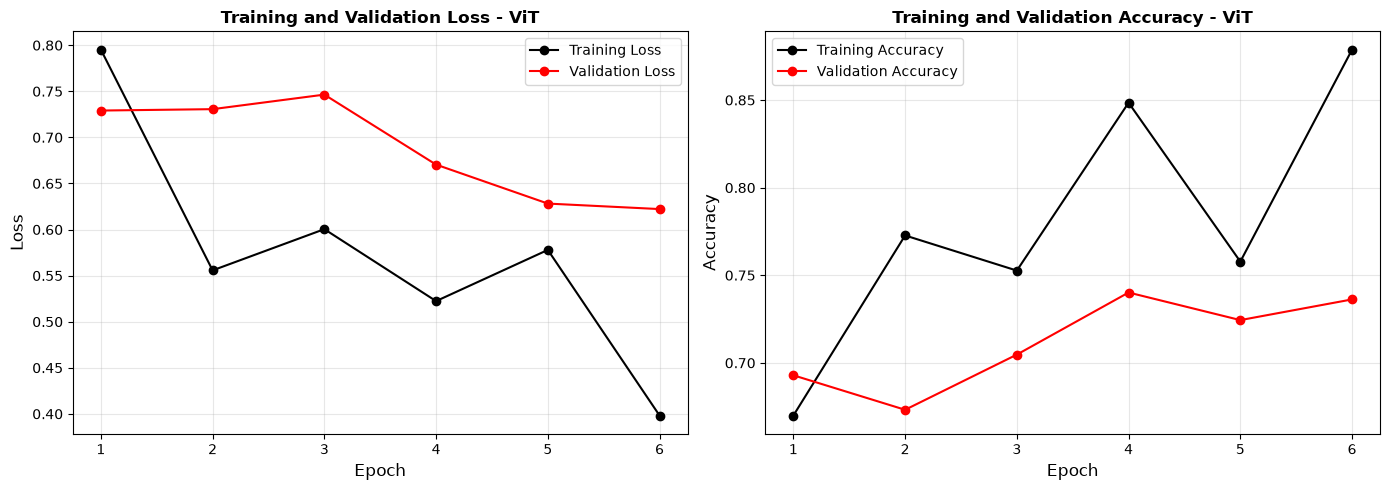

In [41]:
# Plot Training History for ViT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(np.arange(1, EPOCHS + 1), history_vit_tl['loss'],
             color='black', label='Training Loss', marker='o')
axes[0].plot(np.arange(1, EPOCHS + 1), history_vit_tl['val_loss'],
             color='red', label='Validation Loss', marker='o')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss - ViT', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.arange(1, EPOCHS + 1), history_vit_tl['accuracy'],
             color='black', label='Training Accuracy', marker='o')
axes[1].plot(np.arange(1, EPOCHS + 1), history_vit_tl['val_accuracy'],
             color='red', label='Validation Accuracy', marker='o')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy - ViT', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Computing predictions on test set...
Test Accuracy: 0.7490 (74.90%)


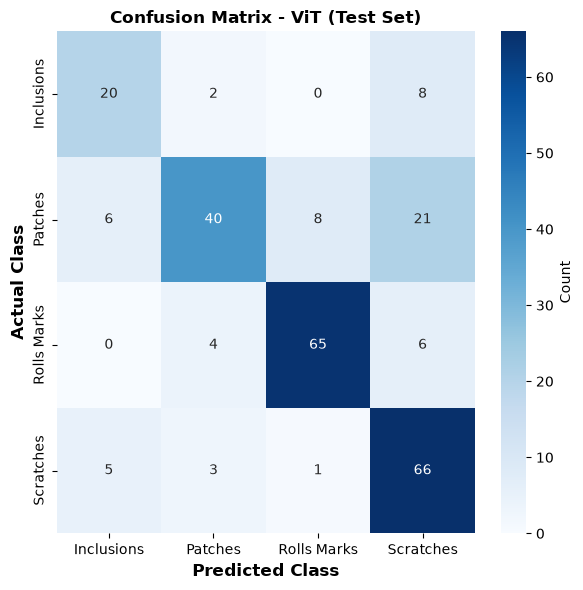


CLASSIFICATION REPORT - ViT (Test Set)
              precision    recall  f1-score   support

  Inclusions     0.6452    0.6667    0.6557        30
     Patches     0.8163    0.5333    0.6452        75
 Rolls Marks     0.8784    0.8667    0.8725        75
   Scratches     0.6535    0.8800    0.7500        75

    accuracy                         0.7490       255
   macro avg     0.7483    0.7367    0.7308       255
weighted avg     0.7665    0.7490    0.7441       255



In [42]:
# Confusion Matrix and Classification Report - ViT (Test)
print("Computing predictions on test set...")
ypred_test, ylabel_test = [], []

for images, labels in test_ds:
    logits = model_vit.predict(images, verbose=0)
    predicted = np.argmax(logits, axis=1)
    ypred_test.extend(predicted)
    ylabel_test.extend(labels.numpy())

cm_test = confusion_matrix(ylabel_test, ypred_test)
test_accuracy = np.sum(np.array(ypred_test) == np.array(ylabel_test)) / len(ylabel_test)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("="*60)

plt.figure(figsize=(6, 6))
sns.heatmap(cm_test, annot=True, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            fmt='d', cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('Actual Class', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - ViT (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CLASSIFICATION REPORT - ViT (Test Set)")
print("="*60)
print(classification_report(ylabel_test, ypred_test,
                             labels=list(range(len(class_names))),
                             target_names=class_names, digits=4))
print("="*60)


In [43]:
# Save ViT Model
model_vit.save('vit_transfer_model.keras')
print("ViT transfer learning model saved as 'vit_transfer_model.keras'")


ViT transfer learning model saved as 'vit_transfer_model.keras'


In [44]:
# ============================================================
# GRAND COMPARISON OF ALL TESTED MODELS
# ============================================================
from sklearn.metrics import f1_score, precision_score, recall_score

# --- Register every trained model with its training history and training time ---
model_registry = {
    "VGG16 (frozen)":      {"model": model_vgg16,    "history": history_vgg16,    "time": time_vgg16},
    "VGG16 (fine-tuned)":  {"model": model_vgg16_ft, "history": history_vgg16_ft, "time": time_vgg16_ft},
    "MobileNetV2":         {"model": model_mbv2,     "history": history_mbv2,     "time": time_mbv2},
    "ResNet50":            {"model": model_resnet,   "history": history_resnet,   "time": time_resnet},
    "ViT-B/16":            {"model": model_vit,      "history": history_vit_tl,   "time": time_vit_tl},
}

def evaluate_on_test(model):
    """Return (accuracy, macro_f1, macro_precision, macro_recall, n_params, n_trainable)."""
    y_pred, y_true = [], []
    for images, labels in test_ds:
        logits = model.predict(images, verbose=0)
        predicted = np.argmax(logits, axis=1)
        y_pred.extend(predicted)
        y_true.extend(labels.numpy())
    y_pred, y_true = np.array(y_pred), np.array(y_true)
    acc  = (y_pred == y_true).mean()
    f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    n_params    = model.count_params()
    n_trainable = sum(int(tf.size(w)) for w in model.trainable_weights)
    return acc, f1, prec, rec, n_params, n_trainable

# --- Build the comparison table ---
rows = []
for name, entry in model_registry.items():
    acc, f1, prec, rec, n_params, n_train = evaluate_on_test(entry["model"])
    hist = entry["history"]
    rows.append({
        "Model": name,
        "Test Accuracy": acc,
        "F1-score": f1,
        "Precision": prec,
        "Recall": rec,
        "Best Val Acc": max(hist["val_accuracy"]) if hist else np.nan,
        "Final Train Acc": hist["accuracy"][-1] if hist else np.nan,
        "Epochs": len(hist["loss"]) if hist else np.nan,
        "Params (M)": n_params / 1e6,
        "Trainable (M)": n_train / 1e6,
        "Training Time (s)": entry["time"],
    })

results_df = pd.DataFrame(rows).reset_index(drop=True)

print("=" * 80)
print("GRAND MODEL COMPARISON  (Test Set)")
print("=" * 80)
with pd.option_context("display.float_format", lambda x: f"{x:.4f}"):
    print(results_df.to_string(index=False))
print("=" * 80)
best_idx = results_df["Test Accuracy"].idxmax()
print(f"Best model: {results_df.iloc[best_idx]['Model']} "
      f"({results_df.iloc[best_idx]['Test Accuracy']*100:.2f}% test accuracy)")


GRAND MODEL COMPARISON  (Test Set)
             Model  Test Accuracy  F1-score  Precision  Recall  Best Val Acc  Final Train Acc  Epochs  Params (M)  Trainable (M)  Training Time (s)
    VGG16 (frozen)         0.6784    0.6544     0.6617  0.6567        0.7047           0.6212       6    136.4906         2.2300           784.5132
VGG16 (fine-tuned)         0.6078    0.5924     0.6397  0.6517        0.6654           0.7273       6    136.4906         9.3094          1207.8839
       MobileNetV2         0.7255    0.6999     0.7105  0.6967        0.7402           0.7879       6      2.5869         0.3290           142.4045
          ResNet50         0.7647    0.7354     0.7847  0.7200        0.8189           0.7879       6     24.1133         0.5256           693.1110
          ViT-B/16         0.7490    0.7308     0.7483  0.7367        0.7402           0.8788       6     85.9965         0.1979          2098.5229
Best model: ResNet50 (76.47% test accuracy)


A compact comparison:

|              | VGG16              | ResNet50                  | MobileNetV2                       | Vision Transformer (ViT-B/16)        |
|--------------|--------------------|---------------------------|-----------------------------------|--------------------------------------|
| Year         | 2014               | 2015                      | 2018                              | 2020                                 |
| Key idea     | Stacked 3×3 convs  | Residual/skip connections | Depthwise separable + inverted residuals | Self-attention over image patches |
| Parameters   | ~138M              | ~25M                      | ~3.4M                             | ~86M                                 |
| Depth        | 16 layers          | 50 layers                 | 53 layers                         | 12 transformer blocks                |
| Designed for | Accuracy, simplicity | Trainable very deep nets | Mobile/edge efficiency            | Global context, scale with big data  |
| Trade-off    | Heavy, slow        | Balanced                  | Lightest, slight accuracy cost    | Data-hungry; needs large pre-training |